In [1]:
import sys
import types
m = types.ModuleType('pyjks')
sys.modules['pyjks'] = m

import os
from dotenv import load_dotenv
import hopsworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()
API_KEY_HS = os.getenv('API_KEY_HS')

project = hopsworks.login(
    api_key_value=API_KEY_HS,
    project="Pearls_AQI_Predictor12",
    host="eu-west.cloud.hopsworks.ai"
)
fs = project.get_feature_store()
fg = fs.get_feature_group("karachi_aqi_openmeteo", version=1)

df = fg.read(online=True)
print(f"Loaded {len(df)} rows")
df.head()

2026-05-23 05:44:54,383 WARNING: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'

2026-05-23 05:44:54,383 WARNING: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

2026-05-23 05:44:54,383 WARNING: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'

2026-05-23 05:44:55,065 WARNING: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'

2026-05-23 05:44:55,337 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'parseString' deprecated - use 'parse_string'
2026-05-23 05:44:55,353 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'
2026-05-23 05:44:57,674 INFO: Initiali

,event_timestamp,pm2_5,pm10,co,no2,so2,o3,european_aqi,wind_speed,wind_direction,temperature,humidity,precipitation,pressure,location,aqi_is_poor,pm25_exceeds_who
0,2013-01-02 12:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.3,43.0,22.7,18.0,0.0,1017.0,Karachi_Lyari,0,0
1,2013-01-04 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.9,46.0,13.1,97.0,0.0,1014.3,Karachi_Lyari,0,0
2,2013-01-09 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.8,7.0,16.4,93.0,0.0,1015.2,Karachi_Lyari,0,0
3,2013-01-13 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,353.0,16.8,31.0,0.0,1015.5,Karachi_Lyari,0,0
4,2013-01-25 17:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,275.0,25.6,24.0,0.0,1017.0,Karachi_Lyari,0,0


Rows with all pollution = 0: 84053/117360 (71.6%)

Data quality by year:
      total_rows  zero_pm25   avg_pm25  zero_pct
year                                            
2013        8760       8760   0.000000     100.0
2014        8760       8760   0.000000     100.0
2015        8760       8760   0.000000     100.0
2016        8784       8784   0.000000     100.0
2017        8760       8760   0.000000     100.0
2018        8760       8760   0.000000     100.0
2019        8760       8760   0.000000     100.0
2020        8784       8784   0.000000     100.0
2021        8760       8760   0.000000     100.0
2022        8760       5165  16.923756      59.0
2023        8760          0  32.670537       0.0
2024        8784          0  26.770128       0.0
2025        8760          0  29.183756       0.0
2026        3408          0  28.966315       0.0


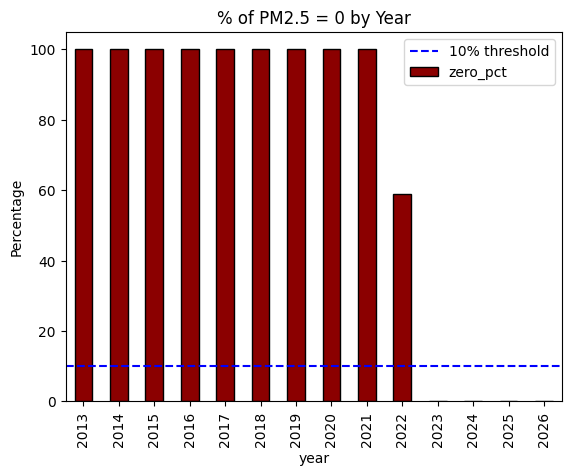

In [2]:
zero_pollution = (df['pm2_5'] == 0) & (df['pm10'] == 0) & (df['co'] == 0)
print(f"Rows with all pollution = 0: {zero_pollution.sum()}/{len(df)} ({zero_pollution.mean()*100:.1f}%)")

df['year'] = df['event_timestamp'].dt.year
yearly_quality = df.groupby('year').agg(
    total_rows=('pm2_5', 'count'),
    zero_pm25=('pm2_5', lambda x: (x == 0).sum()),
    avg_pm25=('pm2_5', 'mean')
)
yearly_quality['zero_pct'] = (yearly_quality['zero_pm25'] / yearly_quality['total_rows'] * 100).round(1)
print("\nData quality by year:")
print(yearly_quality)

import matplotlib.pyplot as plt
yearly_quality['zero_pct'].plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% of PM2.5 = 0 by Year')
plt.ylabel('Percentage')
plt.axhline(y=10, color='blue', linestyle='--', label='10% threshold')
plt.legend()
plt.show()

In [3]:
df = fg.read(online=True)
df['year'] = df['event_timestamp'].dt.year
df = df[df['year'] >= 2023].copy()
print(f"Clean data: {len(df)} rows | Range: {df['event_timestamp'].min()} → {df['event_timestamp'].max()}")

Clean data: 29712 rows | Range: 2023-01-01 00:00:00 → 2026-05-22 23:00:00


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['event_timestamp'].min(), "→", df['event_timestamp'].max())

Shape: (29712, 18)

Columns: ['event_timestamp', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3', 'european_aqi', 'wind_speed', 'wind_direction', 'temperature', 'humidity', 'precipitation', 'pressure', 'location', 'aqi_is_poor', 'pm25_exceeds_who', 'year']

Missing values:
 event_timestamp     0
pm2_5               0
pm10                0
co                  0
no2                 0
so2                 0
o3                  0
european_aqi        0
wind_speed          0
wind_direction      0
temperature         0
humidity            0
precipitation       0
pressure            0
location            0
aqi_is_poor         0
pm25_exceeds_who    0
year                0
dtype: int64

Date range: 2023-01-01 00:00:00 → 2026-05-22 23:00:00


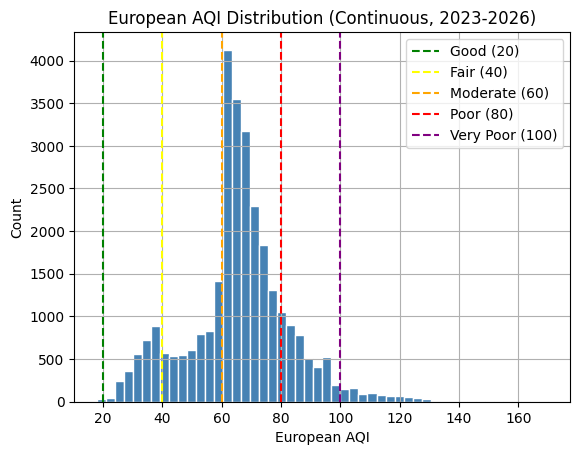

In [5]:
df['european_aqi'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('European AQI Distribution (Continuous, 2023-2026)')
plt.xlabel('European AQI')
plt.ylabel('Count')

plt.axvline(x=20, color='green', linestyle='--', label='Good (20)')
plt.axvline(x=40, color='yellow', linestyle='--', label='Fair (40)')
plt.axvline(x=60, color='orange', linestyle='--', label='Moderate (60)')
plt.axvline(x=80, color='red', linestyle='--', label='Poor (80)')
plt.axvline(x=100, color='purple', linestyle='--', label='Very Poor (100)')
plt.legend()
plt.show()

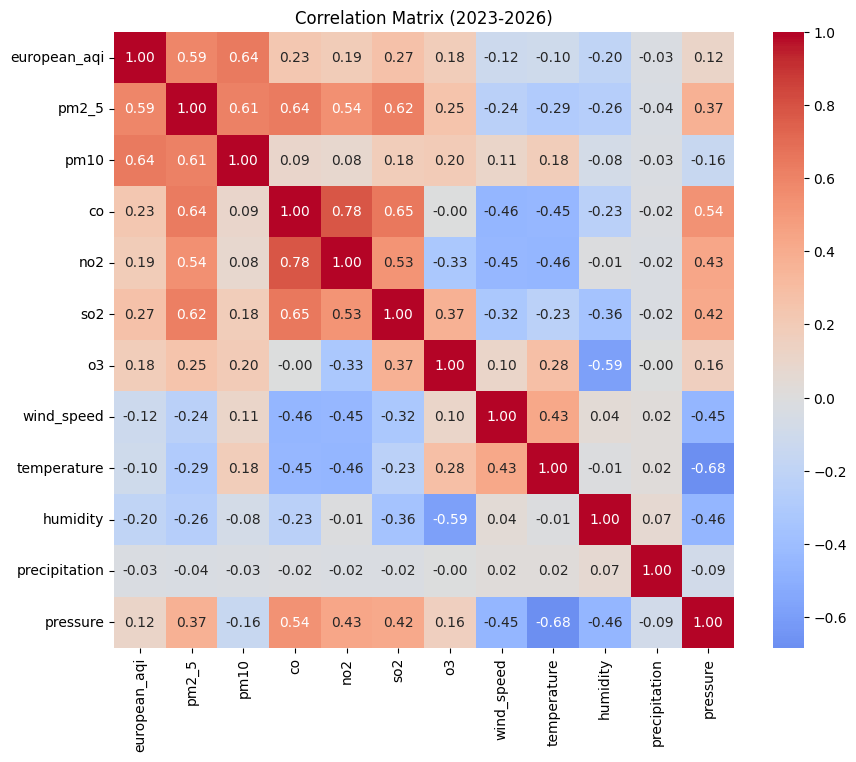

Top correlates with European AQI:
european_aqi     1.000000
pm10             0.640546
pm2_5            0.590054
so2              0.268970
co               0.234911
no2              0.194568
o3               0.182812
pressure         0.116947
precipitation   -0.031928
temperature     -0.104087
Name: european_aqi, dtype: float64


In [6]:
corr_cols = ['european_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3',
             'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (2023-2026)')
plt.show()

print("Top correlates with European AQI:")
print(df[corr_cols].corr()['european_aqi'].sort_values(ascending=False).head(10))

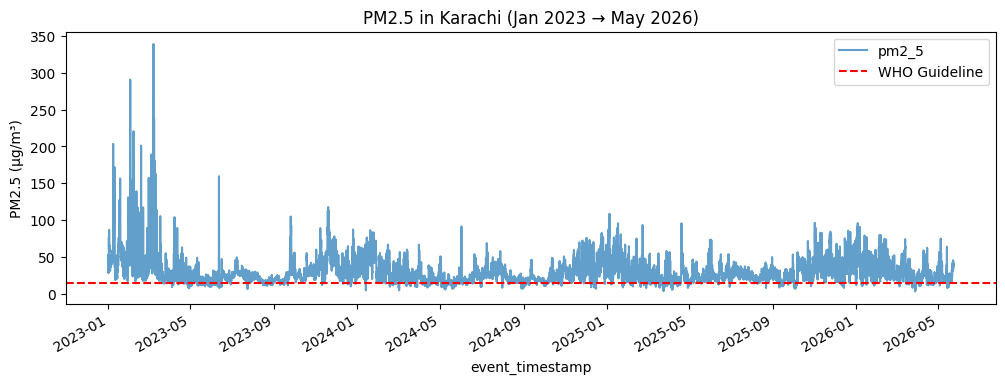

In [7]:
df.set_index('event_timestamp')['pm2_5'].plot(figsize=(12,4), alpha=0.7)
plt.title(f'PM2.5 in Karachi ({df["event_timestamp"].min().strftime("%b %Y")} → {df["event_timestamp"].max().strftime("%b %Y")})')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=15, color='red', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

In [8]:
df['aqi_change_24h'] = df['european_aqi'] - df['european_aqi'].shift(24)
change_corr = df[['wind_speed', 'precipitation', 'temperature', 'pressure', 'aqi_change_24h']].corr()
print("Weather vs AQI CHANGE (not level):")
print(change_corr['aqi_change_24h'].sort_values(ascending=False))

Weather vs AQI CHANGE (not level):
aqi_change_24h    1.000000
pressure          0.078989
precipitation    -0.010968
temperature      -0.088339
wind_speed       -0.116251
Name: aqi_change_24h, dtype: float64


In [9]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

df['month'] = df['event_timestamp'].dt.month
df['hour_of_day'] = df['event_timestamp'].dt.hour
df['day_of_week'] = df['event_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Added: hour_of_day, day_of_week, is_weekend")

Added: hour_of_day, day_of_week, is_weekend


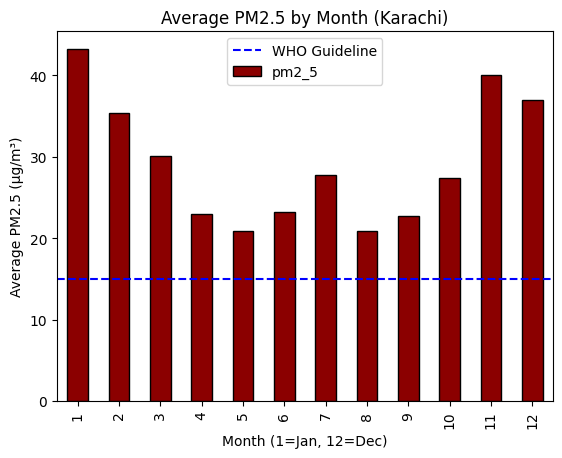

In [10]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm2_5'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM2.5 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.axhline(y=15, color='blue', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

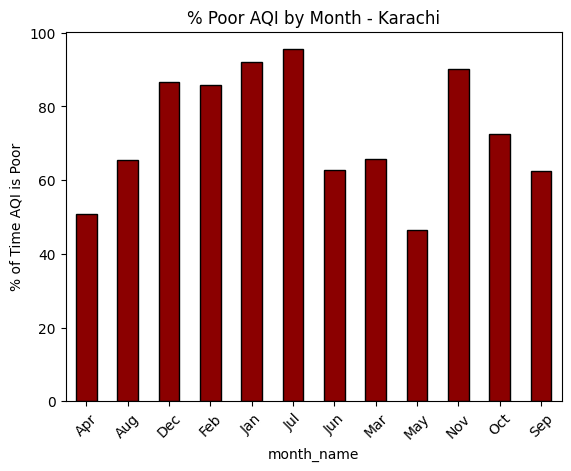

In [11]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['month_name'] = df['month'].map(month_names)

monthly_aqi = df.groupby('month_name')['aqi_is_poor'].mean() * 100
monthly_aqi.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% Poor AQI by Month - Karachi')
plt.ylabel('% of Time AQI is Poor')
plt.xticks(rotation=45)
plt.show()

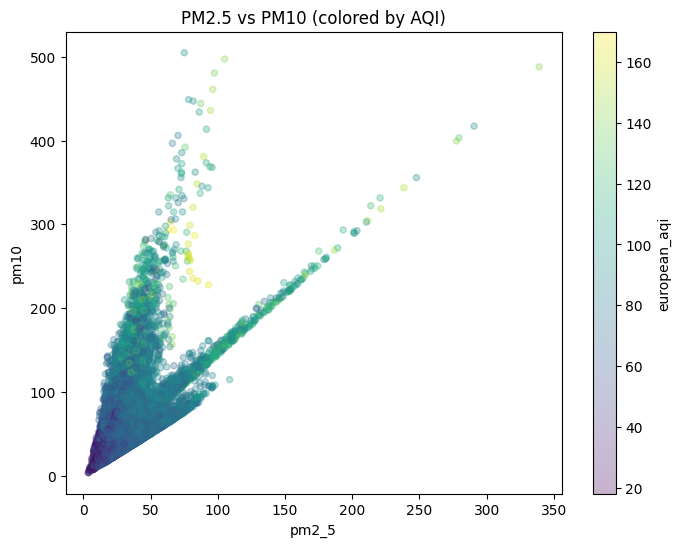

PM10-dominant events: 2421
Average AQI during PM10-dominant: 84.7


In [12]:
df.plot.scatter(x='pm2_5', y='pm10', c='european_aqi', colormap='viridis', alpha=0.3, figsize=(8,6))
plt.title('PM2.5 vs PM10 (colored by AQI)')
plt.show()

df['pm10_dominant'] = (df['pm10'] > 100) & (df['pm2_5'] < 50)
print(f"PM10-dominant events: {df['pm10_dominant'].sum()}")
print(f"Average AQI during PM10-dominant: {df[df['pm10_dominant']]['european_aqi'].mean():.1f}")

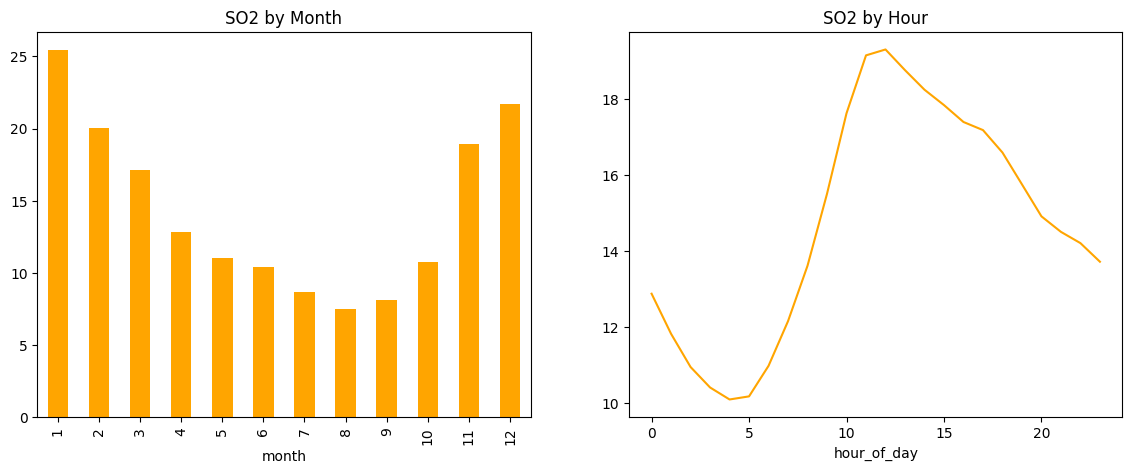

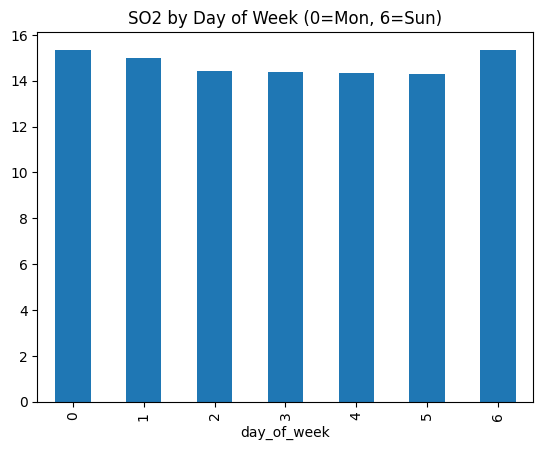

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('month')['so2'].mean().plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title('SO2 by Month')
df.groupby('hour_of_day')['so2'].mean().plot(ax=axes[1], color='orange')
axes[1].set_title('SO2 by Hour')
plt.show()

df.groupby('day_of_week')['so2'].mean().plot(kind='bar')
plt.title('SO2 by Day of Week (0=Mon, 6=Sun)')
plt.show()

In [14]:
may = df[df['month'] == 9]
other_months = df[df['month'] != 9]

print("May vs Rest of Year:")
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2', 'o3']:
    print(f"  {col}: {may[col].mean():.0f} vs {other_months[col].mean():.0f}")

drops = {}
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2']:
    drops[col] = other_months[col].mean() - may[col].mean()
print("\nBiggest drop in May:", max(drops, key=drops.get))

May vs Rest of Year:
  pm2_5: 23 vs 30
  pm10: 66 vs 62
  so2: 8 vs 15
  co: 246 vs 507
  no2: 14 vs 21
  o3: 52 vs 76

Biggest drop in May: co


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_yesterday', 'pm10_yesterday', 'pm25_6h_trend', 'aqi_yesterday',
    'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure',
    'hour_of_day', 'month'
]

df_model = df.dropna(subset=features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

persist_mae = mean_absolute_error(y_test, test['european_aqi'])
print(f"Persistence MAE: {persist_mae:.1f}")

model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
model_mae = mean_absolute_error(y_test, preds)

print(f"Model MAE:      {model_mae:.1f}")
print(f"Improvement:    {'BETTER' if model_mae < persist_mae else 'WORSE'}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(importance.head(5))

Train: 17523 | Test: 12141
Persistence MAE: 16.9
Model MAE:      12.0
Improvement:    BETTER

Top 5 features:
        feature  importance
15        month    0.101913
2           so2    0.087014
13     pressure    0.068779
9    wind_speed    0.061476
10  temperature    0.061413


In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)

df['pm25_2d_ago'] = df['pm2_5'].shift(48)
df['pm25_3d_ago'] = df['pm2_5'].shift(72)
df['aqi_12h_ago'] = df['european_aqi'].shift(12)
df['aqi_2d_ago'] = df['european_aqi'].shift(48)
df['wind_yesterday'] = df['wind_speed'].shift(24)
df['temp_yesterday'] = df['temperature'].shift(24)

df['pressure_24h_change'] = df['pressure'] - df['pressure'].shift(24)
df['temp_24h_change'] = df['temperature'] - df['temperature'].shift(24)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features= [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_yesterday', 'pm25_2d_ago', 'pm10_yesterday',
    'pm25_6h_trend', 'aqi_yesterday', 'aqi_12h_ago',
    'wind_speed', 'wind_yesterday', 'temperature', 'temp_yesterday',
    'humidity', 'precipitation', 'pressure', 'pressure_24h_change',
    'hour_of_day', 'month'
]

df_model = df.dropna(subset=features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

persist_mae = mean_absolute_error(y_test, test['european_aqi'])
print(f"Persistence MAE: {persist_mae:.1f}")

model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
model_mae = mean_absolute_error(y_test, preds)

print(f"Model MAE:      {model_mae:.1f}")
print(f"Improvement:    {'BETTER' if model_mae < persist_mae else 'WORSE'}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(importance.head(5))

Train: 17499 | Test: 12141
Persistence MAE: 16.9
Model MAE:      12.1
Improvement:    BETTER

Top 5 features:
        feature  importance
20        month    0.080393
2           so2    0.064743
17     pressure    0.055526
13  temperature    0.055199
6   pm25_2d_ago    0.050431


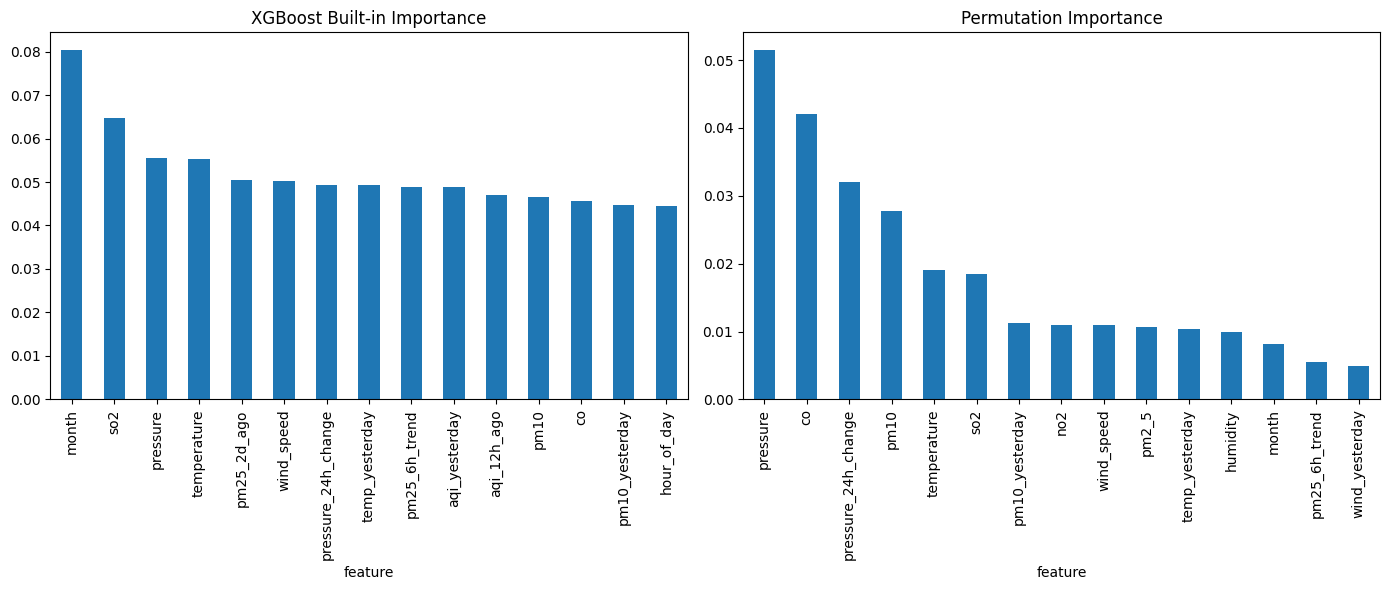

Top features by importance:
  pressure             | Importance: 0.0515
  co                   | Importance: 0.0420
  pressure_24h_change  | Importance: 0.0320
  pm10                 | Importance: 0.0278
  temperature          | Importance: 0.0190
  so2                  | Importance: 0.0185
  pm10_yesterday       | Importance: 0.0112
  no2                  | Importance: 0.0110
  wind_speed           | Importance: 0.0110
  pm2_5                | Importance: 0.0107
Final features (11): ['co', 'no2', 'temperature', 'pressure_24h_change', 'pm10_yesterday', 'wind_speed', 'temp_yesterday', 'pressure', 'pm10', 'so2', 'pm2_5']


In [17]:
from sklearn.inspection import permutation_importance

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

perm_importance = permutation_importance(model, X_test, y_test, n_repeats=3, random_state=42)
perm_df = pd.DataFrame({
    'feature': features,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importance.head(15).plot(kind='bar', x='feature', y='importance', ax=axes[0], legend=False)
axes[0].set_title('XGBoost Built-in Importance')
perm_df.head(15).plot(kind='bar', x='feature', y='importance', ax=axes[1], legend=False)
axes[1].set_title('Permutation Importance')
plt.tight_layout()
plt.show()

perm_df = perm_df.sort_values('importance', ascending=False)
print("Top features by importance:")
for i, row in perm_df.head(10).iterrows():
    print(f"  {row['feature']:20s} | Importance: {row['importance']:.4f}")

top_xgb = set(importance[importance['importance'] > 0.02]['feature'].tolist())
top_perm = set(perm_df[perm_df['importance'] > 0.01]['feature'].tolist())
final_features = list(top_xgb & top_perm)
print(f"Final features ({len(final_features)}): {final_features}")

In [18]:
final_features = ['temperature', 'pressure', 'co', 'pm10_yesterday', 
                  'pm2_5', 'no2', 'pm25_6h_trend', 'so2', 
                  'temp_yesterday', 'pm10', 'month', 'hour_of_day',
                  'wind_speed', 'humidity', 'wind_yesterday']

model_final = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model_final.fit(X_train[final_features], y_train)
preds = model_final.predict(X_test[final_features])
mae = mean_absolute_error(y_test, preds)
print(f"Final MAE: {mae:.1f} (Persistence: 17.0)")

Final MAE: 12.1 (Persistence: 17.0)


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge, Lasso
import numpy as np

final_features = ['temperature', 'pressure', 'co', 'pm10_yesterday', 
                  'pm2_5', 'no2', 'pm25_6h_trend', 'so2', 
                  'temp_yesterday', 'pm10', 'month', 'hour_of_day',
                  'wind_speed', 'humidity', 'wind_yesterday']

models = {
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, verbose=-1),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
}

results = {}
best_model = None
best_mae = float('inf')
best_name = ""

print(f"{'Model':20s} {'MAE':>8s} {'RMSE':>8s} {'R²':>8s}")

for name, model in models.items():
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_name = name
    
    print(f"{name:20s} {mae:8.2f} {rmse:8.2f} {r2:8.3f}")

persist_preds = test['european_aqi']
persist_mae = mean_absolute_error(y_test, persist_preds)
persist_rmse = np.sqrt(mean_squared_error(y_test, persist_preds))
persist_r2 = r2_score(y_test, persist_preds)

print(f"{'Persistence':20s} {persist_mae:8.2f} {persist_rmse:8.2f} {persist_r2:8.3f}")
print(f"\nBest: {best_name} (MAE: {best_mae:.2f})")

summary_df = pd.DataFrame(results).T.round(3)
summary_df.loc['Persistence'] = [persist_mae, persist_rmse, persist_r2]
print(summary_df.sort_values('MAE'))

Model                     MAE     RMSE       R²
XGBoost                 12.08    16.61   -0.122
RandomForest            11.52    16.13   -0.059
GradientBoosting        11.60    16.20   -0.067
LightGBM                11.60    16.16   -0.063
Ridge                   11.35    15.94   -0.034
Lasso                   11.36    15.95   -0.036
Persistence             16.93    22.27   -1.017

Best: Ridge (MAE: 11.35)
                        MAE       RMSE        R²
Ridge             11.354000  15.942000 -0.034000
Lasso             11.359000  15.954000 -0.036000
RandomForest      11.522000  16.129000 -0.059000
LightGBM          11.596000  16.160000 -0.063000
GradientBoosting  11.604000  16.196000 -0.067000
XGBoost           12.082000  16.606000 -0.122000
Persistence       16.932625  22.265149 -1.017102


In [20]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Ridge alpha:")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nLasso alpha:")
for alpha in [0.001, 0.01, 0.1, 1.0]:
    model = Lasso(alpha=alpha, max_iter=5000)
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nRandomForest n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [5, 8, 10]:
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=42, n_jobs=-1)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nGradientBoosting n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 5]:
        model = GradientBoostingRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nXGBoost n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 6, 8]:
        model = XGBRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nLightGBM n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 6]:
        model = LGBMRegressor(n_estimators=n, max_depth=depth, random_state=42, verbose=-1)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

Ridge alpha:
  alpha=0.01: MAE=11.3541: RMSE=15.9423: R2=-0.0341
  alpha=0.10: MAE=11.3541: RMSE=15.9423: R2=-0.0341
  alpha=1.00: MAE=11.3541: RMSE=15.9423: R2=-0.0341
  alpha=10.00: MAE=11.3541: RMSE=15.9423: R2=-0.0341
  alpha=100.00: MAE=11.3541: RMSE=15.9423: R2=-0.0341

Lasso alpha:
  alpha=0.00: MAE=11.3542: RMSE=15.9424: R2=-0.0342
  alpha=0.01: MAE=11.3546: RMSE=15.9434: R2=-0.0343
  alpha=0.10: MAE=11.3593: RMSE=15.9543: R2=-0.0357
  alpha=1.00: MAE=11.4015: RMSE=16.0313: R2=-0.0457

RandomForest n_estimators + depth:
  alpha=1.00: MAE=11.5273: RMSE=16.1358: R2=-0.0594
  alpha=1.00: MAE=11.5188: RMSE=16.1275: R2=-0.0583
  alpha=1.00: MAE=11.5593: RMSE=16.1804: R2=-0.0653
  alpha=1.00: MAE=11.5218: RMSE=16.1294: R2=-0.0586
  alpha=1.00: MAE=11.5322: RMSE=16.1409: R2=-0.0601
  alpha=1.00: MAE=11.5676: RMSE=16.1794: R2=-0.0651
  alpha=1.00: MAE=11.5212: RMSE=16.1286: R2=-0.0584
  alpha=1.00: MAE=11.5325: RMSE=16.1402: R2=-0.0600
  alpha=1.00: MAE=11.5569: RMSE=16.1661: R2=-0.063

In [21]:
poor_pct = df['aqi_is_poor'].mean() * 100
print(f"Karachi has POOR air quality {poor_pct:.1f}% of the time")
print(f"PM2.5 exceeds WHO guidelines {(df['pm25_exceeds_who'].mean() * 100):.1f}% of the time")

Karachi has POOR air quality 72.6% of the time
PM2.5 exceeds WHO guidelines 90.8% of the time


In [22]:
df['is_winter'] = df['month'].isin([11, 12, 1, 2]).astype(int)
df['is_dust_event'] = ((df['pm10'] > 100) & (df['pm2_5'] < 50)).astype(int)
df['is_clean_month'] = (df['month'] == 9).astype(int)
df['is_weekend'] = df['event_timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_morning_peak'] = df['hour_of_day'].between(9, 11).astype(int)

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)
df['temp_yesterday'] = df['temperature'].shift(24)
df['wind_yesterday'] = df['wind_speed'].shift(24)
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_clean_month', 'is_weekend']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4082")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4082 else 'No improvement'}")

Current best MAE: 11.4082
With engineered features: 11.3439
Improvement!


In [23]:
df['is_may'] = (df['month'] == 5).astype(int)

test_features = final_features + ['is_may']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_may']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4019")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4019 else 'No improvement'}")

Current best MAE: 11.4019
With engineered features: 11.3212
Improvement!


In [24]:
df['is_aug'] = (df['month'] == 8).astype(int)

test_features = final_features + ['is_aug']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_aug']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.3801")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.3801 else 'No improvement'}")

Current best MAE: 11.3801
With engineered features: 11.3656
Improvement!


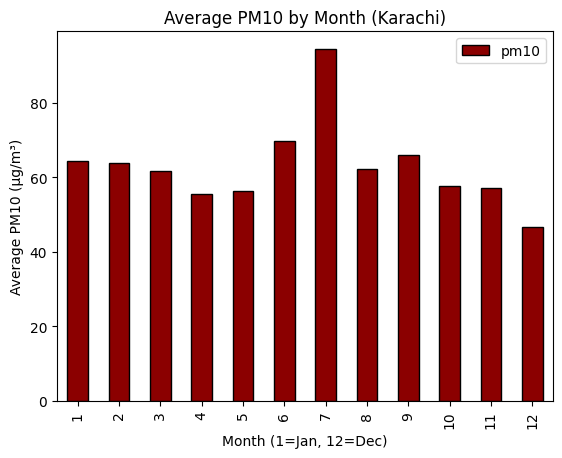

In [25]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm10'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM10 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM10 (µg/m³)')
plt.legend()
plt.show()

In [26]:
df['is_dec'] = (df['month'] == 12).astype(int)

test_features = final_features + ['is_dec']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_dec']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.3801")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.3801 else 'No improvement'}")

Current best MAE: 11.3801
With engineered features: 11.3250
Improvement!


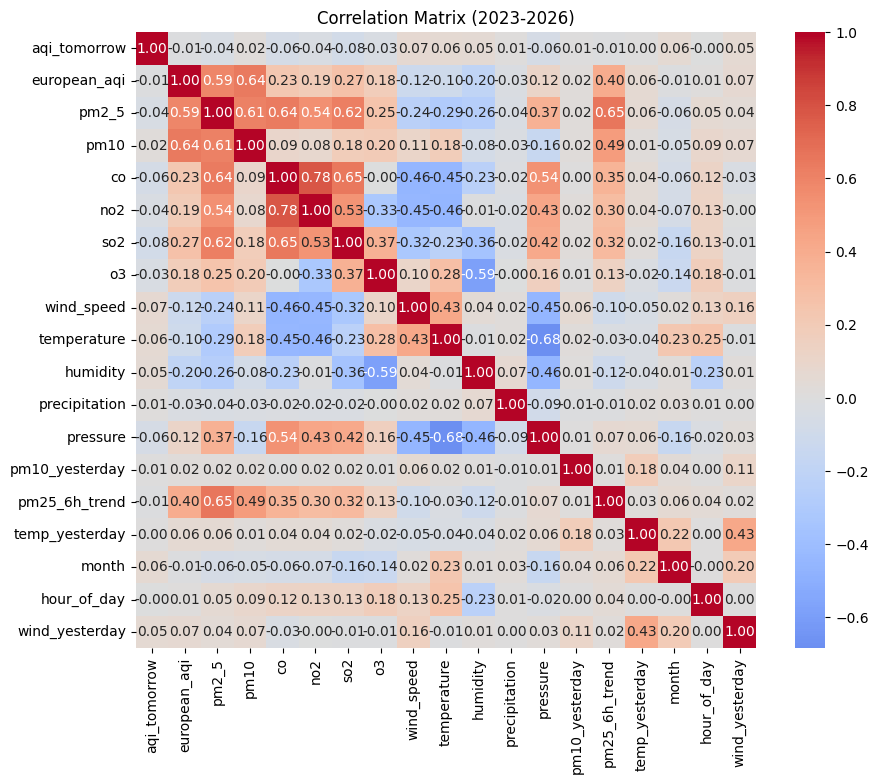

Top correlates with European AQI:
european_aqi      1.000000
pm10              0.640546
pm2_5             0.590054
pm25_6h_trend     0.396263
so2               0.268970
co                0.234911
no2               0.194568
o3                0.182812
pressure          0.116947
wind_yesterday    0.070111
Name: european_aqi, dtype: float64


In [27]:
corr_cols = ['aqi_tomorrow','european_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3',
             'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure', 'pm10_yesterday', 
              'pm25_6h_trend','temp_yesterday', 'month', 'hour_of_day', 'wind_yesterday'   ]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (2023-2026)')
plt.show()

print("Top correlates with European AQI:")
print(df[corr_cols].corr()['european_aqi'].sort_values(ascending=False).head(10))

In [28]:
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow', 'o3'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['o3']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.3801")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.3801 else 'No improvement'}")

Current best MAE: 11.3801
With engineered features: 11.3463
Improvement!


In [33]:
df['pm25_3d_ago'] = df['pm2_5'].shift(72)      # 72 hours = 3 days
df['pm10_3d_ago'] = df['pm10'].shift(72)
df['temp_3d_ago'] = df['temperature'].shift(72)
df['wind_3d_ago'] = df['wind_speed'].shift(72)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features_72h = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_3d_ago', 'pm10_3d_ago', 'temp_3d_ago', 'wind_3d_ago',
    'temperature', 'pressure', 'wind_speed', 'humidity',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

df_model = df.dropna(subset=features_72h + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features_72h].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features_72h].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"With 3-day lags MAE: {mae:.4f}")
print(f"Previous best MAE:   11.3801")

With 3-day lags MAE: 11.2769
Previous best MAE:   11.3801


In [34]:
df['pm25_7d_ago'] = df['pm2_5'].shift(168) 
df['pm10_7d_ago'] = df['pm10'].shift(168)
df['temp_7d_ago'] = df['temperature'].shift(168)
df['wind_7d_ago'] = df['wind_speed'].shift(168)

features_7d = features_72h + ['pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago']

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = Ridge(alpha=1.0)
model.fit(train[features_7d].fillna(0), train['aqi_tomorrow'])
preds = model.predict(test[features_7d].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)

print(f"3-day lags MAE:  11.3447")
print(f"7-day lags MAE:  {mae:.4f}")

3-day lags MAE:  11.3447
7-day lags MAE:  11.2726


In [35]:
df['aqi_3d_ago'] = df['european_aqi'].shift(72)
df['aqi_7d_ago'] = df['european_aqi'].shift(168)

features_test = final_features + ['aqi_3d_ago', 'aqi_7d_ago']

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = Ridge(alpha=1.0)
model.fit(train[features_7d].fillna(0), train['aqi_tomorrow'])
preds = model.predict(test[features_7d].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)

print(f"Without AQI lags: 11.3391")
print(f"With AQI lags:    {mae:.4f}")

Without AQI lags: 11.3391
With AQI lags:    11.2726


In [37]:
# Features that need NO "today" data
df['pm25_3d_ago'] = df['pm2_5'].shift(72)      # 72 hours = 3 days
df['pm10_3d_ago'] = df['pm10'].shift(72)
df['temp_3d_ago'] = df['temperature'].shift(72)
df['wind_3d_ago'] = df['wind_speed'].shift(72)
df['pm25_7d_ago'] = df['pm2_5'].shift(168) 
df['pm10_7d_ago'] = df['pm10'].shift(168)
df['temp_7d_ago'] = df['temperature'].shift(168)
df['wind_7d_ago'] = df['wind_speed'].shift(168)
lag_only_features = [
    'pm25_3d_ago', 'pm10_3d_ago', 'temp_3d_ago', 'wind_3d_ago',
    'pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago',
    'month', 'hour_of_day',
    'is_clean_month', 'is_weekend', 'is_may'
]

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model_lag = Ridge(alpha=1.0)
model_lag.fit(X_train[lag_only_features], y_train)
preds = model_lag.predict(X_test[lag_only_features])
mae = mean_absolute_error(y_test, preds)

print(f"With today's features: 11.35")
print(f"Lag-only features:     {mae:.4f}")

KeyError: "['pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago'] not in index"